In [187]:
#EDA
# Import necessary libraries
import pandas as pd   
import numpy as np   
import seaborn as sns   
import matplotlib.pyplot as plt 
from scipy import stats

In [188]:
# Load the dataset from your local path
df = pd.read_csv("D:/EDA/01-01-2021.csv")
# Print the shape of the dataset
print("Data Shape:", df.shape)
# Display the first 5 rows of the dataset
df.head()

Data Shape: (4011, 14)


,FIPS,Admin2,Province_State,Country_Region,Last_Update,Lat,Long_,Confirmed,Deaths,Recovered,Active,Combined_Key,Incident_Rate,Case_Fatality_Ratio
0,NaN,NaN,NaN,Afghanistan,2021-01-02 05:22:33,33.93911,67.709953,52513,2201,41727,8585,Afghanistan,134.896578,4.191343
1,NaN,NaN,NaN,Albania,2021-01-02 05:22:33,41.15330,20.168300,58316,1181,33634,23501,Albania,2026.409062,2.025173
2,NaN,NaN,NaN,Algeria,2021-01-02 05:22:33,28.03390,1.659600,99897,2762,67395,29740,Algeria,227.809861,2.764848
3,NaN,NaN,NaN,Andorra,2021-01-02 05:22:33,42.50630,1.521800,8117,84,7463,570,Andorra,10505.403482,1.034865
4,NaN,NaN,NaN,Angola,2021-01-02 05:22:33,-11.20270,17.873900,17568,405,11146,6017,Angola,53.452981,2.305328


In [189]:
# Print data types of each column
print("\nData Types:\n", df.dtypes)


Data Types:
 FIPS                   float64
Admin2                  object
Province_State          object
Country_Region          object
Last_Update             object
Lat                    float64
Long_                  float64
Confirmed                int64
Deaths                   int64
Recovered                int64
Active                   int64
Combined_Key            object
Incident_Rate          float64
Case_Fatality_Ratio    float64
dtype: object


In [190]:
# Count missing values in each column
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 FIPS                   746
Admin2                 741
Province_State         178
Country_Region           0
Last_Update              0
Lat                     89
Long_                   89
Confirmed                0
Deaths                   0
Recovered                0
Active                   0
Combined_Key             0
Incident_Rate           89
Case_Fatality_Ratio     48
dtype: int64


In [191]:
# 2. Summary Statistics   
print("\nSummary Stats:\n", df.describe(include='all'))


Summary Stats:
                 FIPS      Admin2 Province_State Country_Region  \
count    3265.000000        3270           3833           4011   
unique           NaN        1925            596            200   
top              NaN  Unassigned          Texas             US   
freq             NaN          51            255           3276   
mean    32386.688208         NaN            NaN            NaN   
std     18017.294540         NaN            NaN            NaN   
min        66.000000         NaN            NaN            NaN   
25%     19049.000000         NaN            NaN            NaN   
50%     30067.000000         NaN            NaN            NaN   
75%     47039.000000         NaN            NaN            NaN   
max     99999.000000         NaN            NaN            NaN   

                Last_Update          Lat        Long_     Confirmed  \
count                  4011  3922.000000  3922.000000  4.011000e+03   
unique                    6          NaN        

In [192]:
# Drop unnecessary columns from dataset
df.drop(['FIPS','Admin2','Province_State','Lat','Long_'], axis=1, inplace=True)
# Display updated dataset
df

,Country_Region,Last_Update,Confirmed,Deaths,Recovered,Active,Combined_Key,Incident_Rate,Case_Fatality_Ratio
0,Afghanistan,2021-01-02 05:22:33,52513,2201,41727,8585,Afghanistan,134.896578,4.191343
1,Albania,2021-01-02 05:22:33,58316,1181,33634,23501,Albania,2026.409062,2.025173
2,Algeria,2021-01-02 05:22:33,99897,2762,67395,29740,Algeria,227.809861,2.764848
3,Andorra,2021-01-02 05:22:33,8117,84,7463,570,Andorra,10505.403482,1.034865
4,Angola,2021-01-02 05:22:33,17568,405,11146,6017,Angola,53.452981,2.305328
...,...,...,...,...,...,...,...,...,...
4006,Ukraine,2021-01-02 05:22:33,0,0,0,0,"Unknown, Ukraine",0.000000,0.000000
4007,Nauru,2021-01-02 05:22:33,0,0,0,0,Nauru,0.000000,0.000000
4008,New Zealand,2021-01-02 05:22:33,0,0,0,0,"Niue, New Zealand",0.000000,0.000000
4009,Tuvalu,2021-01-02 05:22:33,0,0,0,0,Tuvalu,0.000000,0.000000


In [193]:
# Calculate Case Fatality Ratio (CFR)
df['Case_Fatality_Ratio'] = (df['Deaths'] / df['Confirmed']) * 100
# Replace infinite values (division by zero issues) with 0
df['Case_Fatality_Ratio'] = (
    df['Deaths'] / df['Confirmed']
).replace([float('inf'), -float('inf')], 0) * 100
# Fill missing values with 0
df['Case_Fatality_Ratio'] = df['Case_Fatality_Ratio'].fillna(0)
# Check missing values in all columns
df.isnull().sum()

Country_Region          0
Last_Update             0
Confirmed               0
Deaths                  0
Recovered               0
Active                  0
Combined_Key            0
Incident_Rate          89
Case_Fatality_Ratio     0
dtype: int64

In [194]:
# Fill missing Incident_Rate values using country-wise mean
df['Incident_Rate'] = df.groupby('Country_Region')['Incident_Rate'] \
    .transform(lambda x: x.fillna(x.mean()))
# Check remaining missing values
df.isnull().sum()

Country_Region         0
Last_Update            0
Confirmed              0
Deaths                 0
Recovered              0
Active                 0
Combined_Key           0
Incident_Rate          3
Case_Fatality_Ratio    0
dtype: int64

In [195]:
# Show rows where Incident_Rate is missing
df[df['Incident_Rate'].isnull()]

,Country_Region,Last_Update,Confirmed,Deaths,Recovered,Active,Combined_Key,Incident_Rate,Case_Fatality_Ratio
190,Diamond Princess,2021-01-02 05:22:33,712,13,699,0,Diamond Princess,NaN,1.825843
376,MS Zaandam,2021-01-02 05:22:33,9,2,7,0,MS Zaandam,NaN,22.222222
3982,Summer Olympics 2020,2021-01-02 05:22:33,0,0,0,0,Summer Olympics 2020,NaN,0.000000


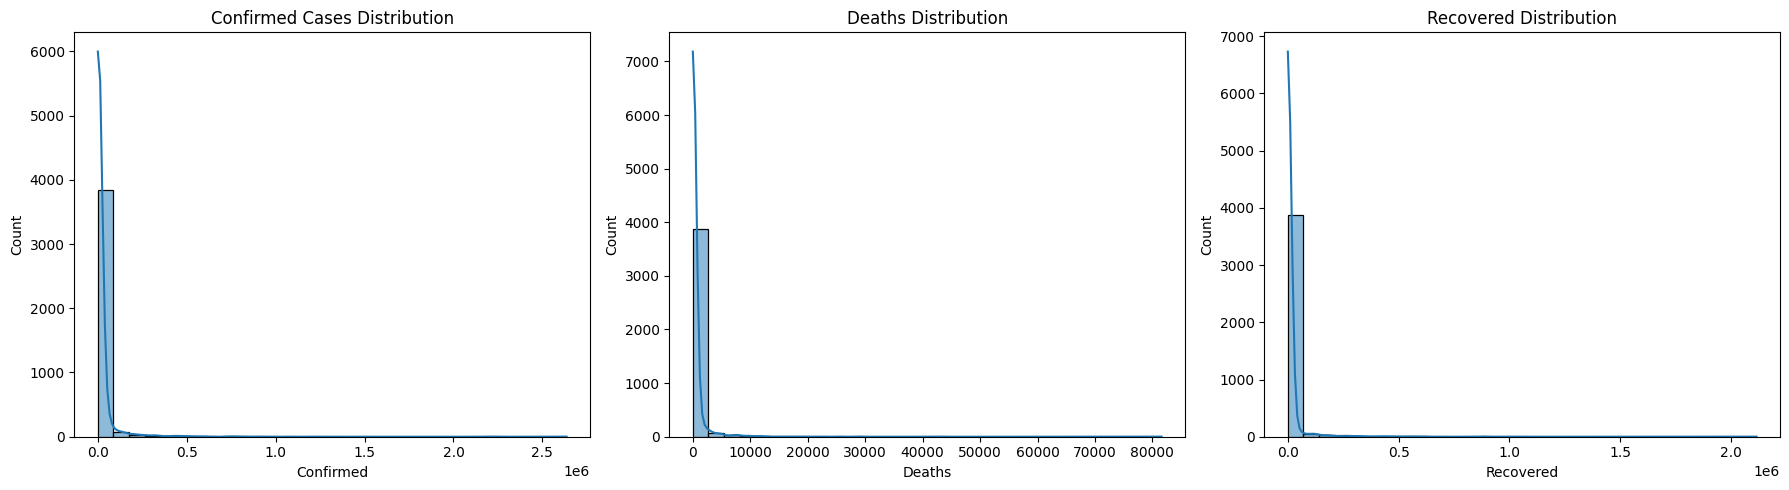

In [196]:
# Create subplots for distributions
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Distribution of Confirmed cases
sns.histplot(df['Confirmed'], bins=30, kde=True, ax=ax[0])
ax[0].set_title('Confirmed Cases Distribution')

# Distribution of Deaths
sns.histplot(df['Deaths'], bins=30, kde=True, ax=ax[1])
ax[1].set_title('Deaths Distribution')

# Distribution of Recovered cases
sns.histplot(df['Recovered'], bins=30, kde=True, ax=ax[2])
ax[2].set_title('Recovered Distribution')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

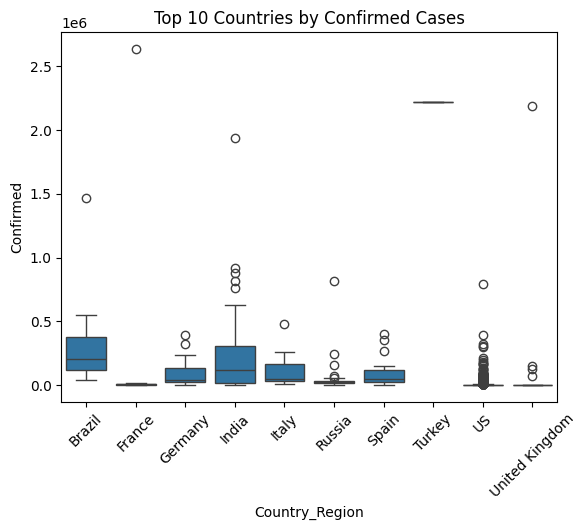

In [197]:
# Get top 10 countries by total confirmed cases
top_countries = df.groupby('Country_Region')['Confirmed'].sum().nlargest(10).index

# Filter dataset for only top 10 countries
df_top = df[df['Country_Region'].isin(top_countries)]

# Boxplot for confirmed cases in top countries
sns.boxplot(x='Country_Region', y='Confirmed', data=df_top)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Set title
plt.title('Top 10 Countries by Confirmed Cases')

# Show plot
plt.show()

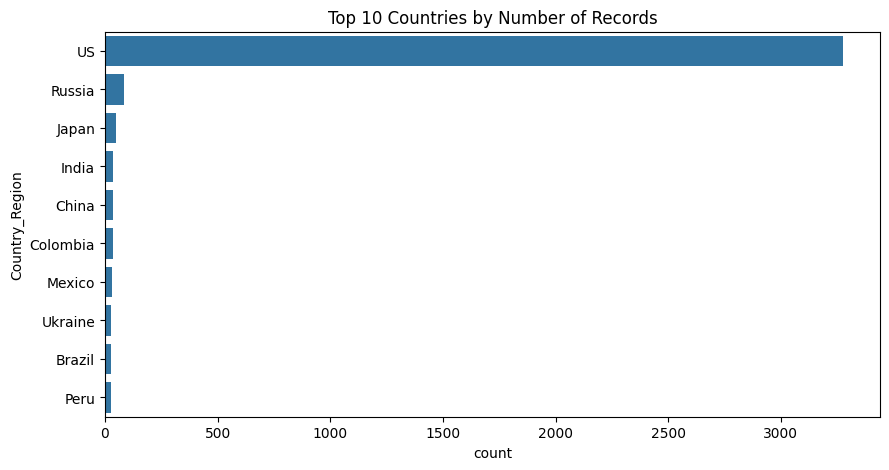

In [198]:
# Set figure size
plt.figure(figsize=(10, 5))

# Countplot for top 10 countries by number of records
sns.countplot(
    y='Country_Region',
    data=df,
    order=df['Country_Region'].value_counts().iloc[:10].index
)

# Set title
plt.title('Top 10 Countries by Number of Records')

# Show plot
plt.show()

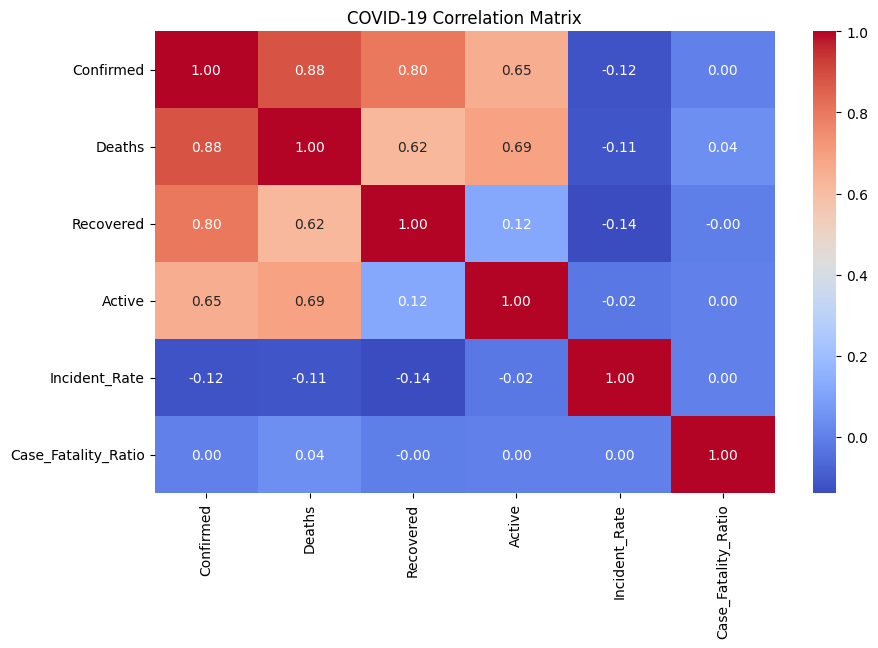

In [199]:
# Set figure size
plt.figure(figsize=(10, 6))

# Compute correlation between numerical columns
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap of correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

# Set title
plt.title('COVID-19 Correlation Matrix')

# Show plot
plt.show()

In [200]:
# Cross-tab: percentage of rows with Active cases > 0 per country
pd.crosstab(df['Country_Region'], df['Active'] > 0, normalize='index') * 100

Active,False,True
Country_Region,,
Afghanistan,0.0,100.0
Albania,0.0,100.0
Algeria,0.0,100.0
Andorra,0.0,100.0
Angola,0.0,100.0
...,...,...
West Bank and Gaza,0.0,100.0
Winter Olympics 2022,100.0,0.0
Yemen,0.0,100.0


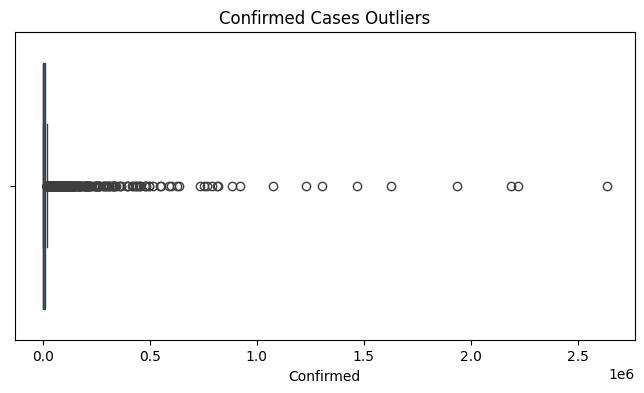

Found 44 confirmed case outliers


In [201]:
# Boxplot to visualize outliers in Confirmed cases
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Confirmed']).set_title('Confirmed Cases Outliers')
plt.show()

# Z-score calculation for detecting outliers
z_scores = np.abs(stats.zscore(df['Confirmed'], nan_policy='omit'))

# Select rows where Z-score > 3 (outliers)
outliers = df[z_scores > 3]

# Print number of outliers found
print(f"Found {len(outliers)} confirmed case outliers")

In [202]:
# Create case severity categories based on Confirmed cases
df['Case_Level'] = pd.cut(
    df['Confirmed'],
    bins=[0, 10000, 100000, df['Confirmed'].max()],
    labels=['Low', 'Medium', 'High']
)


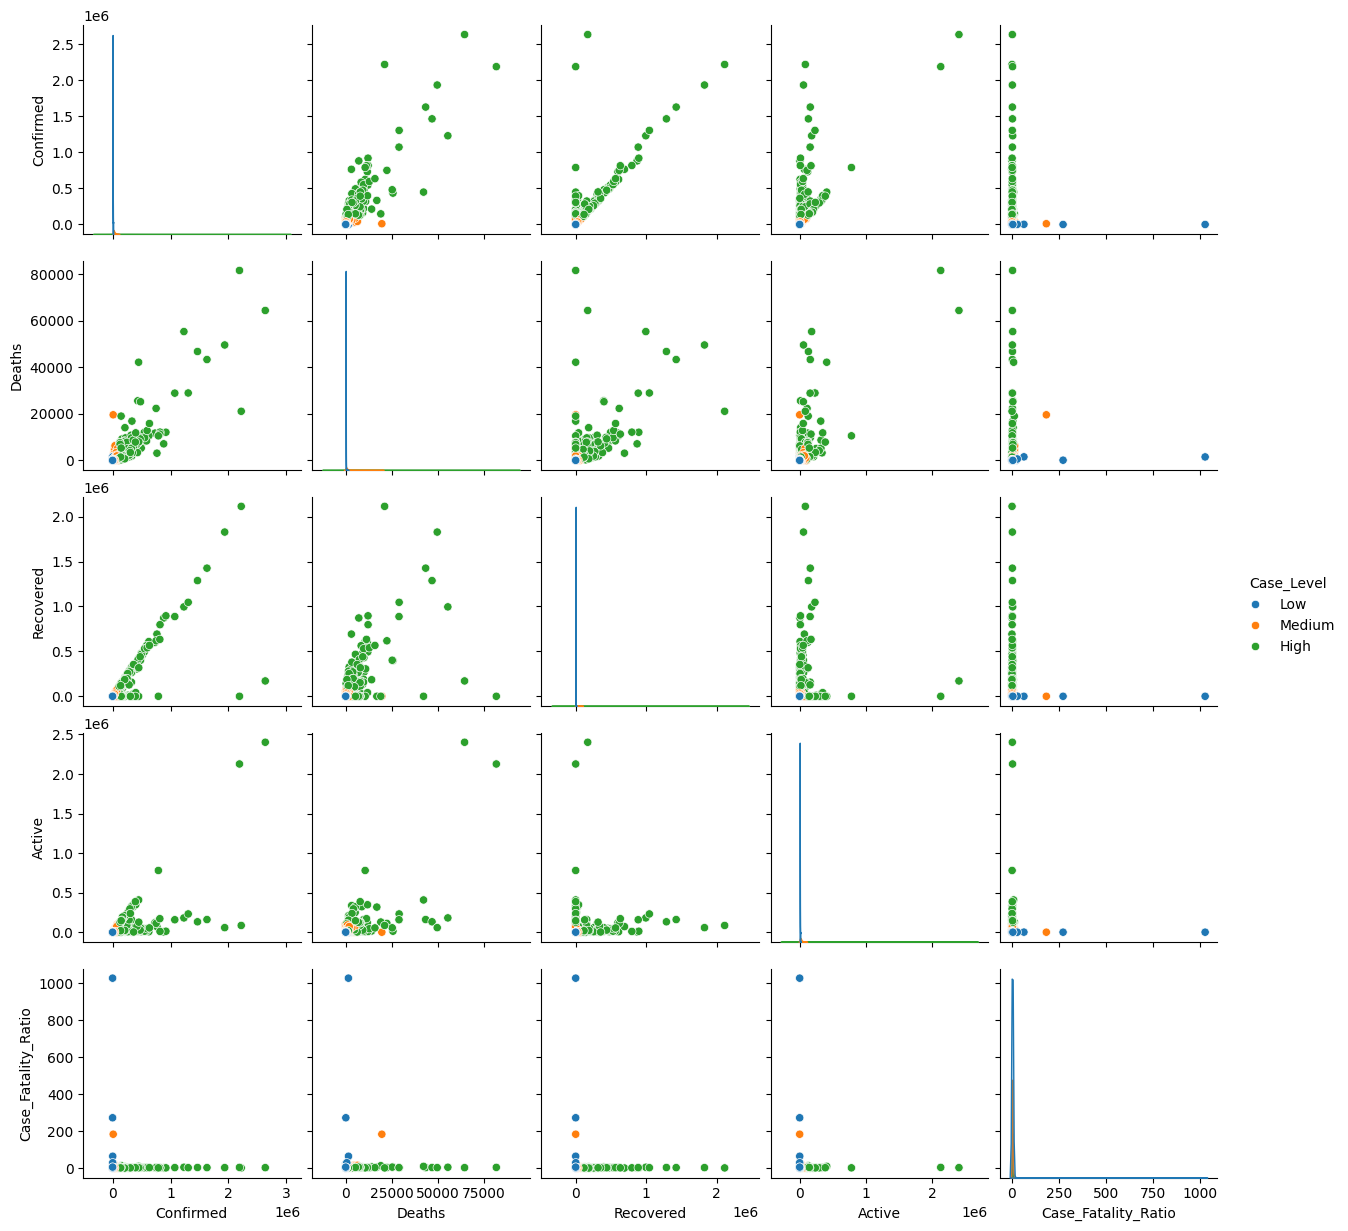

In [203]:
# Pairplot for multivariate relationships
# Use Case_Level (categorical) instead of numeric column for hue
sns.pairplot(
    df[['Confirmed', 'Deaths', 'Recovered', 'Active', 'Case_Fatality_Ratio', 'Case_Level']],
    hue='Case_Level'
)

# Show plot
plt.show()